In [1]:
import torch 
from torch import nn
# import torch_directml
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
# device = torch_directml.device()
# print(device)
# import torch
# print(torch.__version__)

In [2]:
print(torchvision.__version__)

0.19.1+cpu


In [3]:
train_data=datasets.FashionMNIST(
    root="data",  #where do we wanna download our data
    train=True,   #which type of data we want train=True gives training dataset if its false we get testing dataset
    download=True,  #do we wanna download our dataset
    transform=ToTensor(),  #what we wanna transform our data to answer is tensor
    target_transform=None)  #do we wanna transforrm the target/labels
test_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)
#so basically transform does is it changes value from pixel to tensor and store between 0 to 1 by dividing pixel values by 255
#internally 

In [4]:
len(train_data),len(test_data)

(60000, 10000)

In [5]:
image,label=train_data[1]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000,
           0.0000, 0.0000, 0.1608, 0.7373, 0.4039, 0.2118, 0.1882, 0.1686,
           0.3412, 0.6588, 0.5216, 0.0627, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0000, 0.1922,
           0.5333, 0.8588, 0.8471, 0.8941, 0.9255, 1.0000, 1.0000, 1.0000,
           1.0000, 0.8510, 0.8431, 0.9961, 0.9059, 0.6275, 0.1765, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0549, 0.6902, 0.8706,
           0.8784, 0.8314, 0.7961, 0.7765, 0.7686, 0.7843, 0.8431, 0.8000,
           0.7922, 0.7882, 0.7882, 0.7882, 0.8196, 0.8549, 0.8784, 0.6431,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.7373, 0.8588, 0.7843,
           0.7765, 0.7922, 0.7765, 0.7804, 0.7804, 0.7882, 0.7686, 0.7765,
           0.7765, 0.7843, 0.7843, 0.7843, 

In [6]:
classes=train_data.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
# train_data.targets
image.shape,label

(torch.Size([1, 28, 28]), 0)

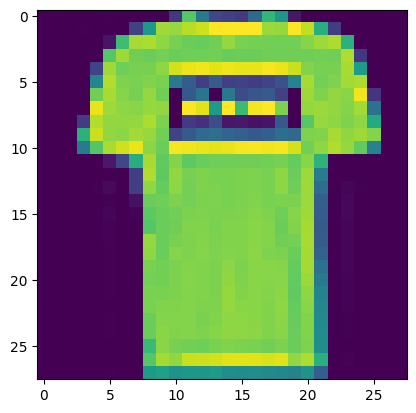

In [8]:
plt.imshow(image.squeeze())

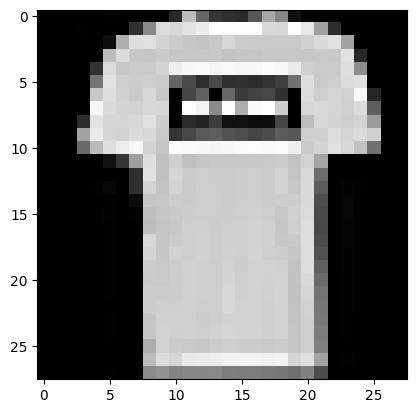

In [9]:
plt.imshow(image.squeeze(),cmap="gray")

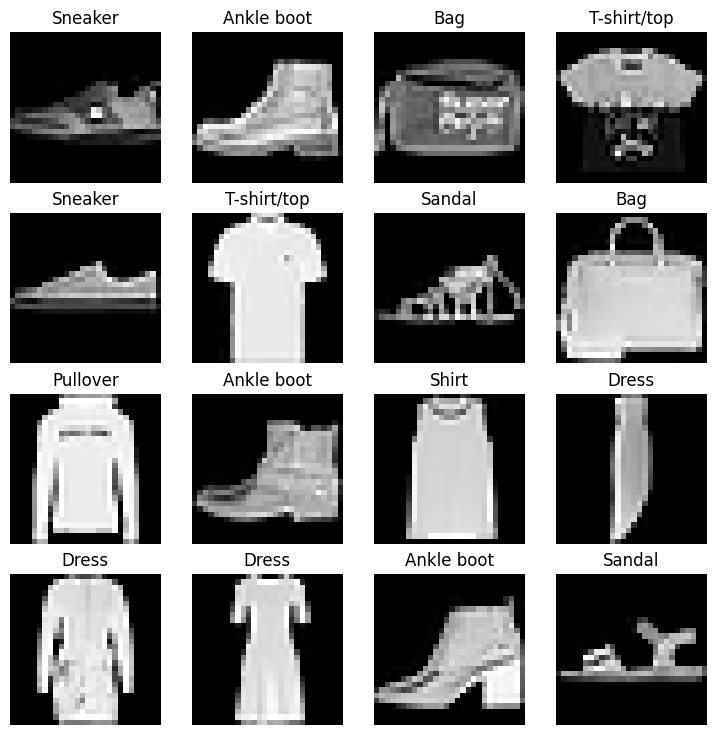

In [10]:
# torch.manual_seed(42)
class_names = [
"T-shirt/top",
"Trouser",
"Pullover",
"Dress",
"Coat",
"Sandal",
"Shirt",
"Sneaker",
"Bag",
"Ankle boot"
]
fig=plt.figure(figsize=(9,9))
rows,cols=4,4
for i in range (1,rows*cols+1):
    random_idx=torch.randint(0,len(train_data),size=[1]).item()
    img,label=train_data[random_idx]
    fig.add_subplot(rows,cols,i)
    plt.imshow(img.squeeze(),cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)

In [11]:
BATCH_SIZE=32
train_dataloader=DataLoader(dataset=train_data,batch_size=32,shuffle=True)
test_dataloader=DataLoader(dataset=test_data,batch_size=32,shuffle=False)
train_dataloader

In [12]:
train_features_batch,train_labels_batch=next(iter(train_dataloader))
train_features_batch.shape,train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

torch.Size([1, 28, 28])

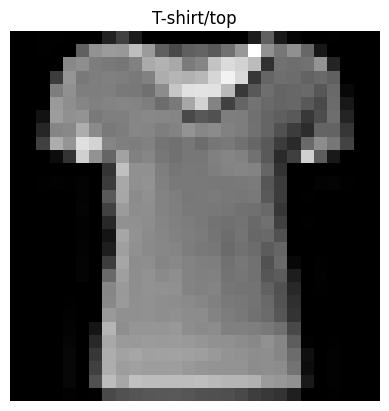

In [13]:
torch.manual_seed(42)
random_idx=torch.randint(0,len(train_features_batch),size=[1]).item()
img,label=train_features_batch[random_idx],train_labels_batch[random_idx]
img,label
plt.imshow(img.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis(False)
img.shape

In [14]:
flatten_model=nn.Flatten()
x=train_features_batch[5]
output=flatten_model(x)
print(f"shape before flatenning : {x.shape}")
print(f"shape before flatenning : {output.shape}")

shape before flatenning : torch.Size([1, 28, 28])
shape before flatenning : torch.Size([1, 784])


In [15]:
class FashionMNISTModel0(nn.Module):
    def __init__(self,
                input_shape:int,
                hidden_units:int,
                output_shape:int):
        super().__init__()
        self.layer_stack=nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=input_shape,
                out_features=hidden_units
            ),
            nn.Linear(
                in_features=hidden_units,
                out_features=output_shape
            )
        )
    def forward(self,x):
        return self.layer_stack(x)

#nn.linear expect a 2D grid but with batch size its 3D so we first pass nn.Flattern to convert it from 1,28,28 to 1,784 

In [16]:
torch.manual_seed(42)
model_0=FashionMNISTModel0(
    input_shape=784, # this is becoz we hve input features height and width in 28*28 format so
    hidden_units=10,
    output_shape=len(class_names)
)
# model_0 = model_0.to(device)

In [17]:
optimizer=torch.optim.Adam(params=model_0.parameters(),lr=0.001)
loss_fn=nn.CrossEntropyLoss()

In [18]:
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc 

In [19]:
from timeit import default_timer as timer
def train_time(start:float,end:float,device:torch.device=None):
    print(f"Total train time = {end-start}")
start_time=timer()
end_time=timer()
train_time(start=start_time,end=end_time)

Total train time = 4.579999949783087e-05


In [20]:
from tqdm.auto import tqdm
train_losses = []
test_losses = []
torch.manual_seed(42)
train_timer_start=timer()
epochs=5
for epoch in tqdm(range(epochs)):
    train_loss=0
    for batch,(X,y) in enumerate (train_dataloader):
        model_0.train()
        y_pred=model_0(X)
        loss=loss_fn(y_pred,y)
        train_loss+=loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss/=len(train_dataloader)
    test_loss,test_acc=0,0
    model_0.eval()

    with torch.inference_mode():
        for X_test,y_test  in test_dataloader:
            test_pred=model_0(X_test)
            test_loss+=loss_fn(test_pred,y_test).item()
            test_acc+=accuracy_fn(y_true=y_test,y_pred=test_pred.argmax(dim=1))
        test_loss/=len(test_dataloader)
        test_acc/=len(test_dataloader)
    print(f"\nTrain Loss: {train_loss} | Test_loss {test_loss} ")
    train_losses.append(train_loss)
    test_losses.append(test_loss)
train_time_end=timer()
toatal_train_time_model_0=train_time(start=train_timer_start,end=train_time_end)


# from tqdm.auto import tqdm
# torch.manual_seed(42)
# train_timer_start=timer()
# epochs=3

# for epoch in tqdm(range(epochs)):
#     train_loss=0
    
#     for batch,(X,y) in enumerate (train_dataloader):
        
#         X = X.to(device)
#         y = y.to(device)
        
#         model_0.train()
#         y_pred=model_0(X)
        
#         loss=loss_fn(y_pred,y)
#         train_loss+=loss
        
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
        
#     if batch%400==0:
#         print(f"{batch}")
        
#     train_loss/=len(train_dataloader)

#     test_loss,test_acc=0,0
#     model_0.eval()
    
#     with torch.no_grad():
        
#         for X_test,y_test  in test_dataloader:
            
#             X_test = X_test.to(device)
#             y_test = y_test.to(device)
            
#             test_pred=model_0(X_test)
            
#             test_loss+=loss_fn(test_pred,y_test)
            
#             test_acc+=accuracy_fn(
#                 y_true=y_test,
#                 y_pred=test_pred.argmax(dim=1)
#             )
            
#         test_loss/=len(test_dataloader)
#         test_acc/=len(test_dataloader)

#     print(f"\nTrain Loss: {train_loss} | Test_loss {test_loss}")

# train_time_end=timer()

# toatal_train_time_model_0=train_time(
#     start=train_timer_start,
#     end=train_time_end
# )

C:\Users\Darsh\anaconda3\envs\torch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 20%|████████████████▊                                                                   | 1/5 [00:33<02:15, 33.89s/it]


Train Loss: 0.6223512505133947 | Test_loss 0.5141275196124951 


 40%|█████████████████████████████████▌                                                  | 2/5 [01:08<01:42, 34.33s/it]


Train Loss: 0.4621017149011294 | Test_loss 0.47821365453945563 


 60%|██████████████████████████████████████████████████▍                                 | 3/5 [01:43<01:08, 34.47s/it]


Train Loss: 0.43798567342758177 | Test_loss 0.4659402313323828 


 80%|███████████████████████████████████████████████████████████████████▏                | 4/5 [02:18<00:34, 34.92s/it]


Train Loss: 0.42389609738588335 | Test_loss 0.45289609297967187 


100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [02:54<00:00, 34.86s/it]


Train Loss: 0.41591718078454337 | Test_loss 0.4505506893173574 
Total train time = 174.29917299999943


In [21]:
def eval_model(
    model: nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn
):
    
    loss, acc = 0, 0
    
    model.eval()
    
    with torch.no_grad():
        for X, y in data_loader:
            
            y_pred = model(X)
            
            loss += loss_fn(y_pred, y).item()
            
            acc += accuracy_fn(
                y_true=y,
                y_pred=y_pred.argmax(dim=1)
            )
    
    loss /= len(data_loader)
    acc /= len(data_loader)
    
    return {
        "model": model.__class__.__name__,
        "model_loss": loss,
        "model_acc": acc
    }
model_0_results=eval_model(model=model_0,data_loader=test_dataloader,loss_fn=loss_fn,accuracy_fn=accuracy_fn)
model_0_results

{'model': 'FashionMNISTModel0',
 'model_loss': 0.4505506893173574,
 'model_acc': 84.22523961661342}

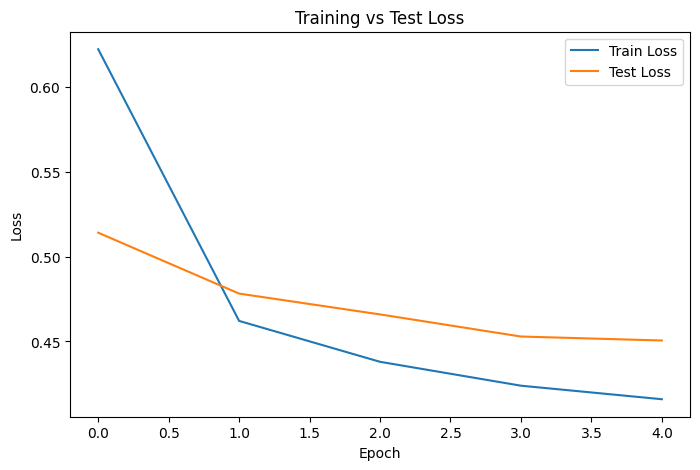

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")

plt.legend()

plt.show()

In [23]:
class FashionMNISTModel1(nn.Module):
    def __init__(self,
                input_shape:int,
                hidden_units:int,
                output_shape:int):
        super().__init__()
        self.layer_stack=nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=input_shape,
                out_features=hidden_units
            ),
            nn.ReLU(),
            nn.Linear(
                in_features=hidden_units,
                out_features=output_shape
            )
        )
    def forward(self,x):
        return self.layer_stack(x)

#nn.linear expect a 2D grid but with batch size its 3D so we first pass nn.Flattern to convert it from 1,28,28 to 1,784 

In [24]:
torch.manual_seed(42)
model_1=FashionMNISTModel1(
    input_shape=784, # this is becoz we hve input features height and width in 28*28 format so
    hidden_units=10,
    output_shape=len(class_names)
)
# model_0 = model_0.to(device)
optimizer=torch.optim.Adam(params=model_1.parameters(),lr=0.001)
loss_fn=nn.CrossEntropyLoss()

In [15]:
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc 

In [16]:
from timeit import default_timer as timer
def train_time(start:float,end:float,device:torch.device=None):
    print(f"Total train time = {end-start}")
start_time=timer()
end_time=timer()
train_time(start=start_time,end=end_time)

Total train time = 5.589999977928528e-05


In [17]:
from tqdm.auto import tqdm
train_losses = []
test_losses = []
torch.manual_seed(42)
train_timer_start=timer()
epochs=5
for epoch in tqdm(range(epochs)):
    train_loss=0
    for batch,(X,y) in enumerate (train_dataloader):
        model_1.train()
        y_pred=model_1(X)
        loss=loss_fn(y_pred,y)
        train_loss+=loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss/=len(train_dataloader)
    test_loss,test_acc=0,0
    model_1.eval()

    with torch.inference_mode():
        for X_test,y_test  in test_dataloader:
            test_pred=model_1(X_test)
            test_loss+=loss_fn(test_pred,y_test).item()
            test_acc+=accuracy_fn(y_true=y_test,y_pred=test_pred.argmax(dim=1))
        test_loss/=len(test_dataloader)
        test_acc/=len(test_dataloader)
    print(f"\nTrain Loss: {train_loss} | Test_loss {test_loss} ")
    train_losses.append(train_loss)
    test_losses.append(test_loss)
train_time_end=timer()
toatal_train_time_model_1=train_time(start=train_timer_start,end=train_time_end)

C:\Users\Darsh\anaconda3\envs\torch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|                                                                                            | 0/5 [00:00<?, ?it/s]


NameError: name 'model_1' is not defined

In [28]:
def eval_model(
    model: nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn
):
    
    loss, acc = 0, 0
    
    model.eval()
    
    with torch.no_grad():
        for X, y in data_loader:
            
            y_pred = model(X)
            
            loss += loss_fn(y_pred, y).item()
            
            acc += accuracy_fn(
                y_true=y,
                y_pred=y_pred.argmax(dim=1)
            )
    
    loss /= len(data_loader)
    acc /= len(data_loader)
    
    return {
        "model": model.__class__.__name__,
        "model_loss": loss,
        "model_acc": acc
    }
model_1_results=eval_model(model=model_1,data_loader=test_dataloader,loss_fn=loss_fn,accuracy_fn=accuracy_fn)
model_1_results

{'model': 'FashionMNISTModel1',
 'model_loss': 0.44726757086313573,
 'model_acc': 84.3650159744409}

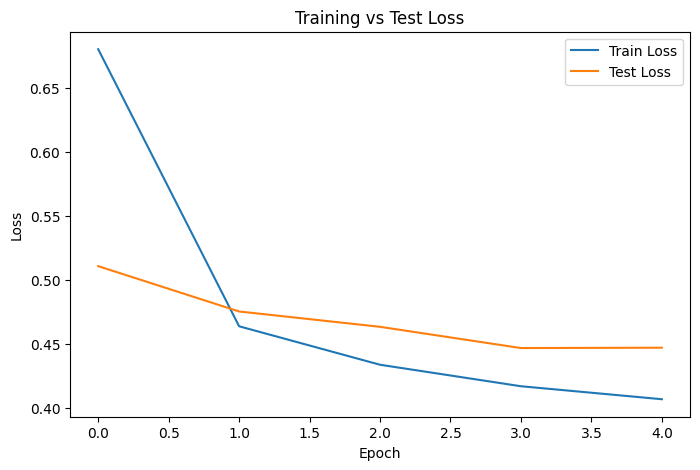

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")

plt.legend()

plt.show()

In [18]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn):
    model.train()
    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(data_loader):
        optimizer.zero_grad()
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss

        train_acc += accuracy_fn(
            y_true=y,
            y_pred=y_pred.argmax(dim=1)
        )
        
        loss.backward()
        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")
    return train_loss.item(), train_acc  # ← add this
def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn):

    test_loss, test_acc = 0, 0
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y)

            test_acc += accuracy_fn(
                y_true=y,
                y_pred=test_pred.argmax(dim=1)
            )
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)

        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")
    return test_loss.item(), test_acc

In [19]:
class FashionMNISTModelV2(nn.Module):
    def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
        super().__init__()
        self.conv1=nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2=nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
            nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
        )
        self.classifier=nn.Sequential(
            nn.Flatten(),    #it just converts the number for further process as linear expect [x,x] means 1d not 3d and 
            #we are multiplying hidden units becoz shape is change of input so
            nn.Linear(in_features=hidden_units*7*7
                      ,out_features=output_shape)
        )
    def forward(self,x):
        x=self.conv1(x)
        # print(x.shape)
        x=self.conv2(x)
        # print(x.shape)
        x=self.classifier(x)
        # print(x.shape)
        return x
#reason we hve multiplied with 4x4 is see in out random image tensor output it gave us shape as [1,10,4,4] as output of our
#covv2d layer after pooling anf after that in our classifier layer we need to give same shape as input as we got from 2nd layer
#as we hve flattern it is 160 and now that 160 is becoz of 2nd layer as it gives us above ans and after multiply we get this
#now as in features are our hidden_units thats 10 but we are giving 160 so for that reason 4*4 we need to multiply if it gave
# us 

In [20]:
torch.manual_seed(42)
# input shape 1 is becoz of how many colour channel we hve
model_2=FashionMNISTModelV2(input_shape=1,hidden_units=10,output_shape=len(class_names))

In [21]:
random_image_tensor=torch.randn(size=(1,28,28))
random_image_tensor.shape

torch.Size([1, 28, 28])

In [22]:
model_2(random_image_tensor.unsqueeze(0))

tensor([[ 0.0366, -0.0940,  0.0686, -0.0485,  0.0068,  0.0290,  0.0132,  0.0084,
         -0.0030, -0.0185]], grad_fn=<AddmmBackward0>)

In [23]:
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc 

In [24]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_2.parameters(),lr=0.1)
# model_2.state_dict()

In [25]:
from tqdm.auto import tqdm
torch.manual_seed(42)
from timeit import default_timer as timer
train_time_start_model_2=timer()
epochs=10
train_losses, train_accs = [], []
test_losses, test_accs   = [], []
for epoch in tqdm(range(epochs)):
    train_loss, train_acc=train_step(model=model_2,
              data_loader=train_dataloader,
              loss_fn=loss_fn,
              optimizer=optimizer,
              accuracy_fn=accuracy_fn)
    test_loss, test_acc =test_step(model=model_2,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn)
    train_losses.append(train_loss)
    train_accs.append(train_acc)     
    test_losses.append(test_loss)    
    test_accs.append(test_acc) 
train_time_end_model_2=timer()
print(f"Total train time : {train_time_end_model_2-train_time_start_model_2}")

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

Train loss: 0.58878 | Train accuracy: 78.60%


 10%|████████▎                                                                          | 1/10 [01:39<14:59, 99.90s/it]

Test loss: 0.40527 | Test accuracy: 85.24%

Train loss: 0.36373 | Train accuracy: 86.93%


 20%|████████████████▍                                                                 | 2/10 [03:20<13:23, 100.45s/it]

...

Test loss: 0.29308 | Test accuracy: 89.61%

Train loss: 0.25827 | Train accuracy: 90.71%


 90%|█████████████████████████████████████████████████████████████████████████▊        | 9/10 [16:14<01:49, 109.31s/it]

Test loss: 0.28723 | Test accuracy: 89.67%

Train loss: 0.25680 | Train accuracy: 90.56%


100%|█████████████████████████████████████████████████████████████████████████████████| 10/10 [18:02<00:00, 108.23s/it]

Test loss: 0.32258 | Test accuracy: 88.69%

Total train time : 1082.3192973999999


In [ ]:
model_2_results=eval_model(model=model_2,
                          data_loader=test_loader,
                          loss_fn=loss_fn,
                          accuracy_fn=accuracy_fn)

In [ ]:
model_0_results

In [26]:
X, y = next(iter(train_dataloader))
optimizer.zero_grad()
y_pred = model_2(X)
loss = loss_fn(y_pred, y)
print("loss before:", loss)
loss.backward()
optimizer.step()

# check loss after one step
y_pred2 = model_2(X)
loss2 = loss_fn(y_pred2, y)
print("loss after:", loss2)


loss before: tensor(0.1117, grad_fn=<NllLossBackward0>)
loss after: tensor(0.0451, grad_fn=<NllLossBackward0>)


In [27]:
# run this first
print(train_losses)
print(test_losses)

# should see something like:
# [0.64, 0.36, 0.32, 0.30, 0.28]
# not []

[0.5887764692306519, 0.3637290894985199, 0.3252700865268707, 0.3053668439388275, 0.2906787395477295, 0.2813938856124878, 0.27344268560409546, 0.2655906677246094, 0.25826698541641235, 0.2567979097366333]
[0.4052663743495941, 0.35710421204566956, 0.3159361183643341, 0.31780701875686646, 0.3044329881668091, 0.30307626724243164, 0.2936120331287384, 0.29307883977890015, 0.28722861409187317, 0.3225763440132141]


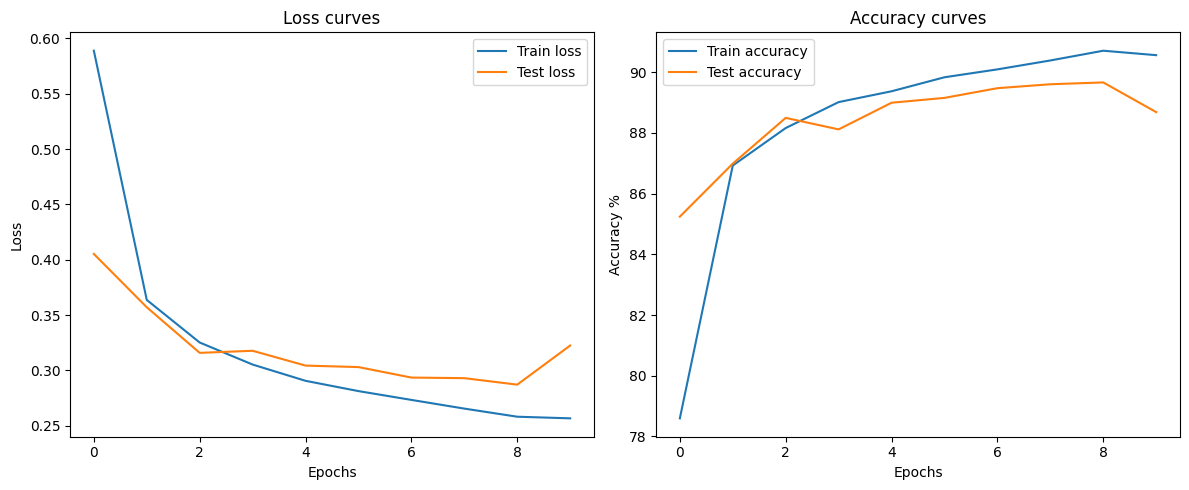

In [28]:
import matplotlib.pyplot as plt

epochs_range = range(epochs)

plt.figure(figsize=(12, 5))

# loss curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train loss")
plt.plot(epochs_range, test_losses,  label="Test loss")
plt.title("Loss curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# accuracy curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, label="Train accuracy")
plt.plot(epochs_range, test_accs,  label="Test accuracy")
plt.title("Accuracy curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy %")
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
def make_prediction(model:torch.nn.Module,
                   data:list):
    pred_probs=[]
    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample=torch.unsqueeze(sample,dim=0)
            pred_logits=model(sample)
            pred_prob=torch.softmax(pred_logits.squeeze(),dim=0)
            pred_probs.append(pred_prob)
    return torch.stack(pred_probs)


In [52]:
import random
# random.seed(42)
test_samples=[]
test_labels=[]

for sample,label in random.sample(list(test_data),k=9):
    test_samples.append(sample)
    test_labels.append(label)
test_samples[0].shape


torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Ankle boot')

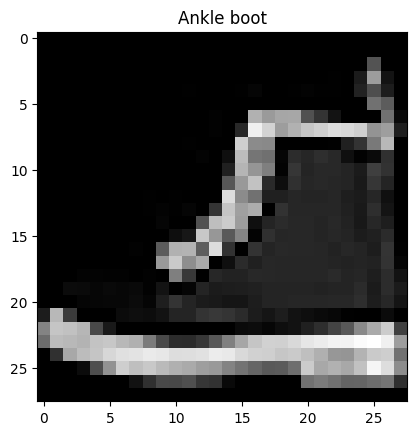

In [53]:
plt.imshow(test_samples[0].squeeze(),cmap="gray")
plt.title(class_names[test_labels[0]])

In [54]:
pred_probs=make_prediction(model=model_2,data=test_samples)
pred_probs[:10]

tensor([[8.8036e-08, 6.7405e-10, 1.3197e-08, 6.2262e-08, 3.0685e-08, 1.9176e-04,
         5.4582e-10, 2.1356e-04, 6.4766e-05, 9.9953e-01],
        [1.4172e-05, 5.5112e-08, 4.7279e-06, 1.2945e-07, 7.4654e-06, 1.3597e-04,
         1.2120e-07, 9.2641e-01, 2.4109e-04, 7.3185e-02],
        [6.1464e-04, 9.6764e-06, 9.9405e-01, 1.4175e-04, 1.4936e-03, 2.3355e-07,
         3.6737e-03, 3.4461e-07, 1.1932e-05, 7.3547e-06],
        [9.4529e-01, 6.3678e-07, 8.9926e-04, 2.2882e-04, 2.7119e-07, 6.9559e-08,
         5.3576e-02, 5.8992e-09, 6.6608e-06, 2.1486e-08],
        [5.0000e-06, 9.9995e-01, 1.2156e-08, 4.0426e-05, 9.0534e-06, 1.4172e-09,
         1.7226e-07, 1.2545e-08, 1.0976e-08, 6.5995e-09],
        [9.8908e-01, 5.4416e-07, 8.1934e-03, 3.8032e-05, 1.5058e-06, 1.4865e-09,
         2.6823e-03, 6.3335e-10, 1.1368e-06, 6.5694e-09],
        [9.6248e-04, 2.4178e-05, 5.1843e-03, 2.9843e-01, 6.9446e-01, 9.8511e-07,
         5.9166e-04, 1.1134e-06, 3.3403e-04, 1.7922e-05],
        [8.2374e-07, 2.0530

In [55]:
pred_classes=pred_probs.argmax(dim=1)
pred_classes

tensor([9, 7, 2, 0, 1, 0, 4, 5, 4])

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

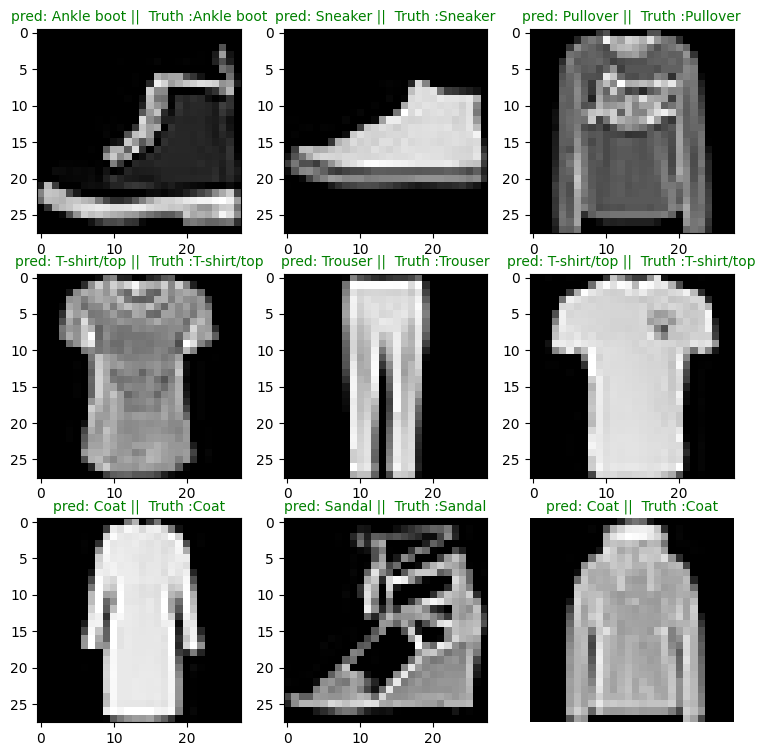

In [57]:
plt.figure(figsize=(9,9))
nrows=3
ncols=3
for i,sample in enumerate(test_samples):
    plt.subplot(nrows,ncols,i+1)
    plt.imshow(sample.squeeze(),cmap="gray")
    pred_label=class_names[pred_classes[i]]
    truth_label=class_names[test_labels[i]]
    title_text=f"pred: {pred_label} ||  Truth :{truth_label}"
    if pred_label==truth_label:
        plt.title(title_text,fontsize=10,c="g") 
    else :
        plt.title(title_text,fontsize=10,c="r")
plt.axis(False)

In [1]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(
    task="multiclass",
    num_classes=len(class_names)
)

confmat_tensor = confmat(
    preds=pred_classes,    # your predictions
    target=test_labels     # true labels
)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)

NameError: name 'class_names' is not defined